In [1]:
import numpy as np
import bilby
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner
import json
import healpy as hp
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
from matplotlib import rc
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18


## N-body maps

In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
from matplotlib.colors import LinearSegmentedColormap
mycmap = LinearSegmentedColormap.from_list("my_cmap", [ska_color_purple, ska_color_pink, ska_color_pink, radio_color])

In [4]:
nside=128 # original dm maps resolution
npix=hp.nside2npix(nside)

/Users/ulyana.dupletsa/miniconda3/envs/icaro_gwfish/lib/python3.9/site-packages/healpy/visufunc.py:1503: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


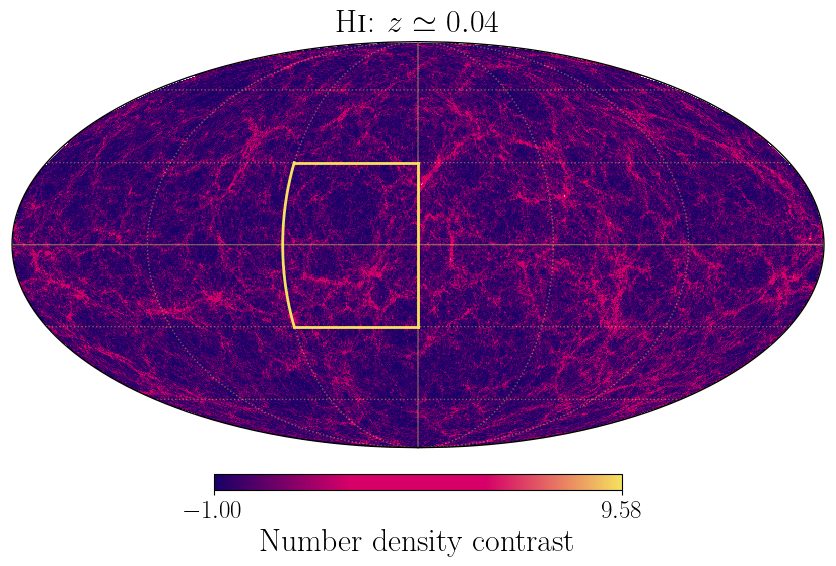

In [5]:
snapshot = 61 #low z map example
count_data = np.loadtxt('../../dm_halos_data/count_map_snapshot61_zmin0.02_zmax0.05_nside128.txt')

mean_count_per_pix= np.sum(count_data)/npix
count_map = (count_data - mean_count_per_pix)/mean_count_per_pix
hp.mollview(count_map,cmap=mycmap,  title=r'\rm $z=0.04$', cbar=True, nest=False, badcolor="none", bgcolor='none')


hp.graticule(dpar=30, dmer=60, verbose=False, color=radio_color, alpha=0.4)  # Ensures grid is added
plt.title(r'\rm {\textrm{H\textsc{i}}}: $z\simeq 0.04$', fontsize=23)  # Adjust font size

# Get the current figure and axes
fig = plt.gcf()
# Healpy puts the colorbar in the last axis
cbar_ax = fig.axes[-1]
# Change colorbar tick label font size
cbar_ax.tick_params(labelsize=18)
# Optional: change colorbar label fontsize (if you set one)
cbar_ax.set_xlabel(r'\rm Number density contrast', fontsize=23)
cbar_ax.xaxis.set_major_formatter(FormatStrFormatter(r'$%.2f$'))

for ax in fig.axes:
    ax.set_facecolor('none')          # axes background
    if hasattr(ax, "patch"):
        ax.patch.set_alpha(0.0)       # THIS is critical

ra_min, ra_max = 0, 60
dec_min, dec_max = -30, 30

# Create boundary lines
ra_vals = np.linspace(ra_min, ra_max, 200)
dec_vals = np.linspace(dec_min, dec_max, 200)

# Bottom and top edges
hp.projplot(ra_vals, np.full_like(ra_vals, dec_min),
            lonlat=True, color=radio_color, linewidth=2)
hp.projplot(ra_vals, np.full_like(ra_vals, dec_max),
            lonlat=True, color=radio_color, linewidth=2)

# Left and right edges
hp.projplot(np.full_like(dec_vals, ra_min), dec_vals,
            lonlat=True, color=radio_color, linewidth=2)
hp.projplot(np.full_like(dec_vals, ra_max), dec_vals,
            lonlat=True, color=radio_color, linewidth=2)


plt.savefig('map_snapshot_%s.pdf' %snapshot, bbox_inches='tight', dpi=300)
plt.show()

/Users/ulyana.dupletsa/miniconda3/envs/icaro_gwfish/lib/python3.9/site-packages/healpy/visufunc.py:1503: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


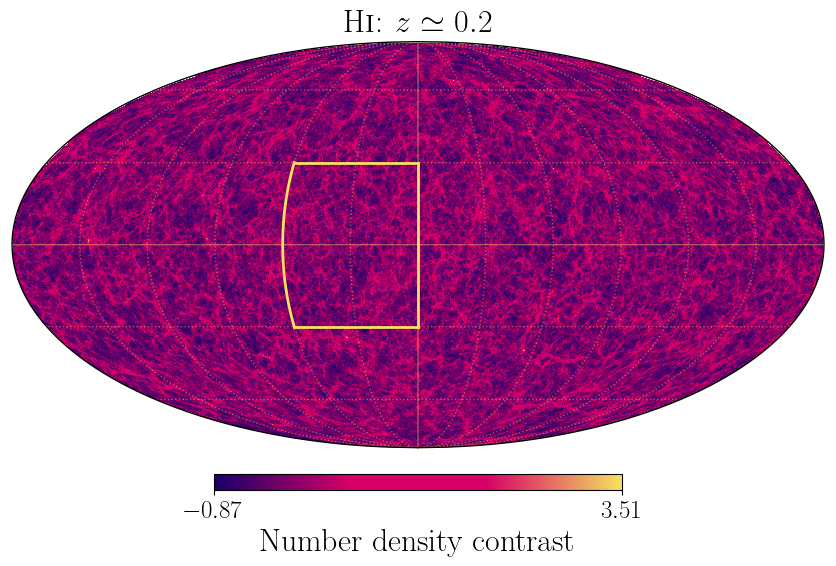

In [6]:
snapshot=55 # high z map example
count_data = np.loadtxt('../../dm_halos_data/count_map_snapshot55_zmin0.19_zmax0.22_nside128.txt')
mean_count_per_pix= np.sum(count_data)/npix
count_map = (count_data - mean_count_per_pix)/mean_count_per_pix
hp.mollview(count_map,cmap=mycmap,  title=r'\rm $z=0.04$', cbar=True, nest=False, badcolor="none", bgcolor='none')
hp.graticule(verbose=False, color=radio_color, alpha=0.4)  # Ensures grid is added

# RA labels (bottom, outside ellipse)
ra_vals = np.arange(0, 360, 60)


# Get the current figure and axes
fig = plt.gcf()
# Healpy puts the colorbar in the last axis
cbar_ax = fig.axes[-1]
# Change colorbar tick label font size
cbar_ax.tick_params(labelsize=18)
# Optional: change colorbar label fontsize (if you set one)
cbar_ax.set_xlabel(r'\rm Number density contrast', fontsize=23)
cbar_ax.xaxis.set_major_formatter(FormatStrFormatter(r'$%.2f$'))

ra_min, ra_max = 0, 60
dec_min, dec_max = -30, 30

# Create boundary lines
ra_vals = np.linspace(ra_min, ra_max, 200)
dec_vals = np.linspace(dec_min, dec_max, 200)

# Bottom and top edges
hp.projplot(ra_vals, np.full_like(ra_vals, dec_min),
            lonlat=True, color=radio_color, linewidth=2)
hp.projplot(ra_vals, np.full_like(ra_vals, dec_max),
            lonlat=True, color=radio_color, linewidth=2)

# Left and right edges
hp.projplot(np.full_like(dec_vals, ra_min), dec_vals,
            lonlat=True, color=radio_color, linewidth=2)
hp.projplot(np.full_like(dec_vals, ra_max), dec_vals,
            lonlat=True, color=radio_color, linewidth=2)


plt.title(r'\rm {\textrm{H\textsc{i}}}: $z\simeq 0.2$', fontsize=23)  # Adjust font size
plt.savefig('map_snapshot_%s.pdf' %snapshot, bbox_inches='tight', dpi=300)
plt.show()